<a href="https://colab.research.google.com/github/fickas/crab_project/blob/main/notebooks/saltmarsh_crab_wellfleet_band_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run experiments on different band configurations

Note this is set up for model 1 training but could easily be switched to model 2 training by changing paths. Might consider a switch test_model1 True or False and set paths accordingly.

In [1]:
# Cell 1 — repo + dependencies
!git clone https://github.com/fickas/crab_project.git /content/marsh-crab 2>/dev/null || \
 (cd /content/marsh-crab && git pull)
!pip install -r /content/marsh-crab/requirements.txt


remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 6 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 2.52 KiB | 1.26 MiB/s, done.
From https://github.com/fickas/crab_project
   450fc39..ab03266  main       -> origin/main
Updating 450fc39..ab03266
Fast-forward
 band_experiments.py | 100 ++++++++++++++++++++++++----------------------------
 1 file changed, 47 insertions(+), 53 deletions(-)


#Wait until marsh-crab shows up locally

In [2]:
# Cell 2 — Python setup
import sys
sys.path.insert(0, '/content/marsh-crab')
import marsh_utils as mu
import band_experiments as be

##Run on changes

In [3]:
# Run this cell whenever you edit the repo
!cd /content/marsh-crab && git pull
import importlib
importlib.reload(mu)
importlib.reload(be)

Already up to date.


<module 'band_experiments' from '/content/marsh-crab/band_experiments.py'>

In [4]:
import torch

In [5]:
# Settings
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu128


In [6]:
BATCH_SIZE = mu.recommended_batch_size()
BATCH_SIZE

GPU: Tesla T4  (15.6 GB VRAM)


4

In [7]:
base = "/content/drive/MyDrive/salt_marsh/crab_project/WEL/"

In [8]:
model1_test = True

In [9]:
if model1_test:

  # Define paths to all expected input files
  paths = {
      # Smoke test (existing data)
      "smoke_dem":         f"{base}/dem_folder/17May21_WEL_Low_P4_DEM.tif",
      "smoke_tile_labels": f"{base}/labels/master_grid.shp",

      # Production drone imagery (forthcoming)
      "ms_orthomosaic":    f"{base}/wellfleet_high_res/ms_5band.tif",       # 2 cm, B/G/R/RE/NIR stacked
      "pan_orthomosaic":   f"{base}/wellfleet_high_res/pan.tif",             # 1 cm, single band
      "pansharp_ms":       f"{base}/wellfleet_high_res/pansharp_5band.tif",  # 1 cm, B/G/R/RE/NIR stacked
      "dem_high_res":      f"{base}/wellfleet_high_res/dem_5m.tif",          # ?

      # Labels
      "crab_polygons":     f"{base}/wellfleet_high_res/crab_polygons.shp",

      # Optional: existing centerlines or other reference data
      "channel_centerlines": f"{base}/wellfleet_high_res/channel_centerlines.shp",

      # Output locations
      "runs_dir": f"{base}/wellfleet_high_res/runs",
      "out_dir":  f'{base}/wellfleet_high_res/runs/band_experiments'
  }

else:
    paths = {}  #fill in with model2 paths


#Synthetic data until have real


In [10]:
synthetic = True

In [11]:
if synthetic and model1_test:
  paths["ms_orthomosaic"] =     f"{base}/synthetic_test/wellfleet_high_res_synthetic/ms_5band.tif"
  paths["pansharp_ms"] =        f"{base}/synthetic_test/wellfleet_high_res_synthetic/pansharp_5band.tif"  # 1 cm, B/G/R/RE/NIR stacked
  paths["dem_high_res"] =       f"{base}/synthetic_test/wellfleet_high_res_synthetic/dem_5m.tif"
  paths['pan_orthomosaic'] =    f'{base}/synthetic_test/wellfleet_high_res_synthetic/pan.tif'
  paths['crab_polygons'] =      f'{base}/synthetic_test/wellfleet_high_res_synthetic/crab_polygons.shp'
  paths['channel_centerlines'] = f'{base}/synthetic_test/wellfleet_high_res_synthetic/channel_centerlines.shp'
  paths["runs_dir"] = f"{base}/synthetic_test/wellfleet_high_res_synthetic/runs"
  paths["out_dir"] = f'{base}/synthetic_test/wellfleet_high_res_synthetic/runs/band_experiments'

elif synthetic:
  paths = {}   #fill in with model2 paths


In [12]:
import os
# Create output directories
for key in ["runs_dir"]:
    os.makedirs(paths[key], exist_ok=True)

# Verify which input files exist (you'll have some, not others)
print("File existence check:")
for key, path in paths.items():
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    print(f"  {status} {key}: {path}")

File existence check:
  ✓ smoke_dem: /content/drive/MyDrive/salt_marsh/crab_project/WEL//dem_folder/17May21_WEL_Low_P4_DEM.tif
  ✗ smoke_tile_labels: /content/drive/MyDrive/salt_marsh/crab_project/WEL//labels/master_grid.shp
  ✓ ms_orthomosaic: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ms_5band.tif
  ✓ pan_orthomosaic: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/pan.tif
  ✓ pansharp_ms: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/pansharp_5band.tif
  ✓ dem_high_res: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/dem_5m.tif
  ✓ crab_polygons: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/crab_polygons.shp
  ✗ channel_centerlines: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/channel_ce

In [13]:
import rasterio
EXPECTED = ['Blue', 'Green', 'Red', 'RedEdge', 'NIR']

with rasterio.open(paths["ms_orthomosaic"]) as src:
    print(src.count)         # 5
    print(src.descriptions)  # band names if the pipeline set them

    all_bands = src.read()           # whole raster, shape (5, H, W)
    nir_only  = src.read(5)          # just NIR, shape (H, W)
    print(all_bands.shape, nir_only.shape)

    if all(src.descriptions): assert list(src.descriptions) == EXPECTED, src.descriptions

5
('Blue', 'Green', 'Red', 'RedEdge', 'NIR')
(5, 3000, 3000) (3000, 3000)


In [14]:
class Config:
    # Class scheme — taken from marsh_utils (project-wide, not per-run)
    CLASS_COLUMN        = 'Class'
    CLASS_NAMES         = mu.CLASS_NAMES
    CLASSES             = mu.CLASSES
    CLASSES_OF_INTEREST = mu.CLASSES_OF_INTEREST
    PRIORITY            = mu.PRIORITY
    IGNORE_INDEX        = mu.IGNORE_INDEX
    QGIS_TO_MODEL       = mu.QGIS_TO_MODEL
    N_CLASSES           = len(mu.CLASSES)

    SEED = mu.SEED

    # Per-run knobs (stay in notebook so you can edit and re-run)
    RESOLUTION_CM = 1.0
    BAND_SPEC    = [('pan_orthomosaic', 1), ('ndvi', 1), ('ndre', 1)]
    PATCH_SIZE   = 512
    OVERLAP      = 0.5
    BATCH_SIZE   = BATCH_SIZE
    EPOCHS        = 30            #smaller for testing
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY  = 1e-4
    NUM_WORKERS   = 4

    # Loss
    CE_WEIGHT   = 1.0
    DICE_WEIGHT = 1.0

    # Augmentation
    USE_D4_AUGMENTATION = True
    ENCODER      = 'efficientnet-b3'
    ENCODER_WEIGHTS = 'imagenet'

    # Splitting
    BLOCK_SIZE_M   = 3 if synthetic else 100
    TRAIN_FRAC     = 0.7
    VAL_FRAC       = 0.15
    TEST_FRAC      = 0.15
    REQUIRE_LABELS = True

    # Populated post-training (filled by pick_thresholds, etc.)
    CONFIDENCE_THRESHOLDS = None

In [15]:
import geopandas as gpd


In [16]:
tiles_gdf = gpd.read_file(paths['crab_polygons'])

print(tiles_gdf.columns.tolist())
print(tiles_gdf.iloc[0])
print(tiles_gdf[Config.CLASS_COLUMN].value_counts())

['Class', 'geometry']
Class                                                       3
geometry    POLYGON ((409997.8904621168 4642475.553464215,...
Name: 0, dtype: object
Class
2    32
4    26
3    16
5    13
6    11
1     1
Name: count, dtype: int64


##Compute derived bands and save to disk (or just load)

In [17]:
paths = mu.ensure_indices(paths)
print(paths['ndvi'])
print(paths['ndre'])

NDVI:
  exists, skipping: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ndvi.tif
NDRE:
  exists, skipping: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ndre.tif
/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ndvi.tif
/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ndre.tif


##More bands
<pre>
Config.BAND_SPEC = [
    ('pan_orthomosaic', 1),
    ('ndvi',            1),
    ('slope',           1),      # ← swap in
    ('savi',            1),      # ← or add a 4th
]
</pre>

In [18]:
# ── Spectral indices (read from pansharp_ms) ──
mu.ensure_savi(paths,       ms_key='pansharp_ms')
mu.ensure_evi(paths,        ms_key='pansharp_ms')
mu.ensure_gndvi(paths,      ms_key='pansharp_ms')
mu.ensure_ndwi(paths,       ms_key='pansharp_ms')
mu.ensure_ci_rededge(paths, ms_key='pansharp_ms')

# ── DEM-derived ──
mu.ensure_tpi(paths, dem_key='dem_high_res', neighborhood_m=0.05, out_key='tpi_micro')
mu.ensure_tpi(paths, dem_key='dem_high_res', neighborhood_m=0.3,  out_key='tpi_small')
mu.ensure_tpi(paths, dem_key='dem_high_res', neighborhood_m=2.0,  out_key='tpi_large')

# Optional, only if you want a non-redundant slope signal:
# mu.ensure_slope(paths, dem_key='dem_high_res', smooth_sigma_m=0.05, out_key='slope')

# QGIS visualization only — don't put in BAND_SPEC:
mu.ensure_hillshade(paths, dem_key='dem_high_res')

# ── Channel-dependent (order matters: ndwi → channel_mask → the rest) ──
mu.ensure_ndwi(paths, ms_key='pansharp_ms')               # if not already done
mu.ensure_channel_mask_from_ndwi(paths, ndwi_key='ndwi')  # needs ndwi
mu.ensure_distance_to_channel(paths, channel_mask_key='channel_mask')
mu.ensure_relative_elevation(paths, dem_key='dem_high_res',
                                    channel_mask_key='channel_mask')

# ── Texture (from pan or any single-band raster) ──
mu.ensure_local_std(paths,  src_key='pan_orthomosaic', window_m=0.3)
mu.ensure_laplacian(paths,  src_key='pan_orthomosaic')

# Texture from pan brightness
mu.ensure_local_range(paths, src_key='pan_orthomosaic', window_m=0.3, out_key='pan_range')

# Topographic micro-relief (burrows!) from DEM
mu.ensure_local_range(paths, src_key='dem_high_res',    window_m=0.3, out_key='dem_range')

# Entropy of pan = visual texture complexity
mu.ensure_local_entropy(paths, src_key='pan_orthomosaic', window_m=0.3, out_key='pan_entropy')

# Existing function — DEM roughness via std
mu.ensure_local_std(paths, src_key='dem_high_res', window_m=0.3, out_key='dem_roughness')

  SAVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/savi.tif, skipping
  EVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/evi.tif, skipping
  GNDVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/gndvi.tif, skipping
  NDWI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ndwi.tif, skipping
  CIred-edge already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ci_rededge.tif, skipping
  TPI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/tpi_micro.tif, skipping
  TPI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/tpi_small.tif, skipping


{'smoke_dem': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//dem_folder/17May21_WEL_Low_P4_DEM.tif',
 'smoke_tile_labels': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//labels/master_grid.shp',
 'ms_orthomosaic': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/ms_5band.tif',
 'pan_orthomosaic': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/pan.tif',
 'pansharp_ms': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/pansharp_5band.tif',
 'dem_high_res': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/dem_5m.tif',
 'crab_polygons': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/crab_polygons.shp',
 'channel_centerlines': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/channel_centerline

In [19]:
new_keys = ['savi', 'evi', 'gndvi', 'ndwi', 'ci_rededge',
            'tpi_micro', 'tpi_small', 'tpi_large',
            'hillshade', 'channel_mask', 'dist_to_channel',
            'rel_elevation', 'local_std', 'laplacian']
missing = [k for k in new_keys if k not in paths]
print(f"Missing: {missing or 'none — all bands registered'}")

Missing: none — all bands registered


In [20]:
polys_gdf = tiles_gdf

###Map to 0-based

In [21]:
# Map QGIS-side class values (1..6) to model class indices (0..5)
QGIS_TO_MODEL = {i:i-1 for i in range(1, len(Config.CLASS_NAMES)+1)}
print(f'{QGIS_TO_MODEL=}')

polys_gdf[Config.CLASS_COLUMN] = polys_gdf[Config.CLASS_COLUMN].map(QGIS_TO_MODEL)

# Catch unmapped values before they become silent bugs
if polys_gdf[Config.CLASS_COLUMN].isna().any():
    bad = polys_gdf.loc[polys_gdf[Config.CLASS_COLUMN].isna(), Config.CLASS_COLUMN].unique()
    raise ValueError(f"Unmapped class values from QGIS: {bad}")

polys_gdf[Config.CLASS_COLUMN] = polys_gdf[Config.CLASS_COLUMN].astype(int)

print(f"Class distribution:\n{polys_gdf[Config.CLASS_COLUMN].value_counts().sort_index()}")


QGIS_TO_MODEL={1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
Class distribution:
Class
0     1
1    32
2    16
3    26
4    13
5    11
Name: count, dtype: int64


In [22]:
for d in be.EXAMPLE_EXPERIMENTS:
  print(d)
  print()

{'name': '01_baseline_pan_ndvi_ndre', 'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('ndre', 1)], 'setup': []}

{'name': '02_pan_ndvi_savi', 'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('savi', 1)], 'setup': [('ensure_savi', {'ms_key': 'pansharp_ms'})]}

{'name': '03_pan_ndvi_tpi_small', 'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('tpi_small', 1)], 'setup': [('ensure_tpi', {'dem_key': 'dem_high_res', 'neighborhood_m': 0.3, 'out_key': 'tpi_small'})]}

{'name': '04_pan_ndvi_tpi_small_large', 'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('tpi_small', 1), ('tpi_large', 1)], 'setup': [('ensure_tpi', {'dem_key': 'dem_high_res', 'neighborhood_m': 0.3, 'out_key': 'tpi_small'}), ('ensure_tpi', {'dem_key': 'dem_high_res', 'neighborhood_m': 2.0, 'out_key': 'tpi_large'})]}

{'name': '05_pan_savi_tpi_small_dist', 'band_spec': [('pan_orthomosaic', 1), ('savi', 1), ('tpi_small', 1), ('dist_to_channel', 1)], 'setup': [('ensure_savi', {'ms_key': 'pansharp_ms'}), ('ensure_tpi',

<img src='https://www.dropbox.com/scl/fi/anhxl9sbzch96mnl4lbvh/Screenshot-2026-06-08-at-10.30.23-AM.png?rlkey=vw0zbcgyjkkzuo3z3wvheu4wy&dl=1'>,

In [23]:
NEW_EXPERIMENTS = [

    # ═══ Q1: Which spectral index pairs best with NDVI? ═══
    {
        'name': '06_pan_ndvi_gndvi',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('gndvi', 1)],
        'setup': [
            ('ensure_gndvi', {'ms_key': 'pansharp_ms'}),
        ],
    },
    {
        'name': '07_pan_ndvi_ci_rededge',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('ci_rededge', 1)],
        'setup': [
            ('ensure_ci_rededge', {'ms_key': 'pansharp_ms'}),
        ],
    },
    {
        'name': '08_pan_ndvi_ndwi',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('ndwi', 1)],
        'setup': [
            ('ensure_ndwi', {'ms_key': 'pansharp_ms'}),
        ],
    },
    {
        'name': '09_pan_ndvi_evi',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('evi', 1)],
        'setup': [
            ('ensure_evi', {'ms_key': 'pansharp_ms'}),
        ],
    },

    # ═══ Q2: Which DEM-roughness metric helps most? ═══
    {
        'name': '10_pan_ndvi_dem_tri',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('dem_tri', 1)],
        'setup': [
            ('ensure_dem_tri', {'dem_key': 'dem_high_res', 'out_key': 'dem_tri'}),
        ],
    },
    {
        'name': '11_pan_ndvi_dem_range',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('dem_range', 1)],
        'setup': [
            ('ensure_local_range', {'src_key': 'dem_high_res', 'window_m': 0.3,
                                    'out_key': 'dem_range'}),
        ],
    },
    {
        'name': '12_pan_ndvi_dem_roughness',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('dem_roughness', 1)],
        'setup': [
            ('ensure_local_std', {'src_key': 'dem_high_res', 'window_m': 0.3,
                                  'out_key': 'dem_roughness'}),
        ],
    },

    # ═══ Q3: Does pan-based texture help? ═══
    {
        'name': '13_pan_ndvi_pan_entropy',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('pan_entropy', 1)],
        'setup': [
            ('ensure_local_entropy', {'src_key': 'pan_orthomosaic', 'window_m': 0.3,
                                      'out_key': 'pan_entropy'}),
        ],
    },
    {
        'name': '14_pan_ndvi_pan_range',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('pan_range', 1)],
        'setup': [
            ('ensure_local_range', {'src_key': 'pan_orthomosaic', 'window_m': 0.3,
                                    'out_key': 'pan_range'}),
        ],
    },
    {
        'name': '15_pan_ndvi_laplacian',
        'band_spec': [('pan_orthomosaic', 1), ('ndvi', 1), ('laplacian', 1)],
        'setup': [
            ('ensure_laplacian', {'src_key': 'pan_orthomosaic'}),
        ],
    },

    # ═══ Q4: Combined DEM-roughness stack ═══
    {
        'name': '16_pan_ndvi_dem_tri_dem_range',
        'band_spec': [
            ('pan_orthomosaic', 1), ('ndvi', 1),
            ('dem_tri', 1), ('dem_range', 1),
        ],
        'setup': [
            ('ensure_dem_tri',     {'dem_key': 'dem_high_res', 'out_key': 'dem_tri'}),
            ('ensure_local_range', {'src_key': 'dem_high_res',  'window_m': 0.3,
                                    'out_key': 'dem_range'}),
        ],
    },

    # ═══ Q5: Full geomorphology — channel-aware ═══
    {
        'name': '17_full_geomorphology',
        'band_spec': [
            ('pan_orthomosaic', 1), ('ndvi', 1),
            ('dem_tri', 1), ('dist_to_channel', 1), ('rel_elevation', 1),
        ],
        'setup': [
            ('ensure_dem_tri', {'dem_key': 'dem_high_res', 'out_key': 'dem_tri'}),
            ('ensure_ndwi', {'ms_key': 'pansharp_ms'}),
            ('ensure_channel_mask_from_ndwi', {'ndwi_key': 'ndwi'}),
            ('ensure_distance_to_channel',    {'channel_mask_key': 'channel_mask'}),
            ('ensure_relative_elevation', {'dem_key': 'dem_high_res',
                                           'channel_mask_key': 'channel_mask'}),
        ],
    },

    # ═══ Q6: Multi-domain mix — best guess for real data ═══
    {
        'name': '18_multi_domain',
        'band_spec': [
            ('pan_orthomosaic', 1),
            ('savi', 1),
            ('dem_tri', 1),
            ('dist_to_channel', 1),
            ('pan_entropy', 1),
        ],
        'setup': [
            ('ensure_savi', {'ms_key': 'pansharp_ms'}),
            ('ensure_dem_tri', {'dem_key': 'dem_high_res', 'out_key': 'dem_tri'}),
            ('ensure_ndwi', {'ms_key': 'pansharp_ms'}),
            ('ensure_channel_mask_from_ndwi', {'ndwi_key': 'ndwi'}),
            ('ensure_distance_to_channel',    {'channel_mask_key': 'channel_mask'}),
            ('ensure_local_entropy', {'src_key': 'pan_orthomosaic', 'window_m': 0.3,
                                      'out_key': 'pan_entropy'}),
        ],
    },
]

In [24]:
# Cell 4 — define experiments (copy from be.EXAMPLE_EXPERIMENTS, edit)
#experiments = be.EXAMPLE_EXPERIMENTS + NEW_EXPERIMENTS
experiments = be.EXAMPLE_EXPERIMENTS

# Cell 5 — run them all
results_df = be.run_band_experiments(
    experiments     = experiments,
    base_paths      = paths,
    polygons_gdf    = polys_gdf,
    config_class    = Config,
    output_dir_root = paths["out_dir"],
    device          = device,
)

# Cell 6 — inspect
display(results_df.sort_values('best_val_miou', ascending=False))

Building patches (one-time, shared across all experiments)...
  Patches: train=287, val=68, test=64

[01_baseline_pan_ndvi_ndre] already complete, loading cached summary
[02_pan_ndvi_savi] already complete, loading cached summary
[03_pan_ndvi_tpi_small] already complete, loading cached summary
[04_pan_ndvi_tpi_small_large] already complete, loading cached summary
[05_pan_savi_tpi_small_dist] already complete, loading cached summary

Wrote summary CSV → /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/runs/band_experiments/experiments_summary.csv
                       name  n_bands                                             bands  best_val_miou  best_epoch  train_min  iou_other  iou_healthy_bank  iou_eroding_non_crab  iou_crab_edge  iou_crab_platform  iou_collapsed
  01_baseline_pan_ndvi_ndre        3                       pan_orthomosaic, ndvi, ndre       0.758976          20  10.622059        0.0          0.903075              0.782283 

,name,n_bands,bands,best_val_miou,best_epoch,train_min,iou_other,iou_healthy_bank,iou_eroding_non_crab,iou_crab_edge,iou_crab_platform,iou_collapsed
1,02_pan_ndvi_savi,3,"pan_orthomosaic, ndvi, savi",0.782892,24,8.246383,0.0,0.903441,0.893776,0.729017,0.766535,0.853123
0,01_baseline_pan_ndvi_ndre,3,"pan_orthomosaic, ndvi, ndre",0.758976,20,10.622059,0.0,0.903075,0.782283,0.700311,0.734184,0.842433
2,03_pan_ndvi_tpi_small,3,"pan_orthomosaic, ndvi, tpi_small",0.700467,27,8.169888,0.0,0.909740,0.853495,0.637928,0.644264,0.819210
4,05_pan_savi_tpi_small_dist,4,"pan_orthomosaic, savi, tpi_small, dist_to_channel",0.635033,29,8.383973,0.0,0.910975,0.897319,0.566654,0.474312,0.864131
3,04_pan_ndvi_tpi_small_large,4,"pan_orthomosaic, ndvi, tpi_small, tpi_large",0.502560,28,8.402338,0.0,0.897594,0.802700,0.506267,0.138402,0.863011


In [26]:
results = be.load_band_experiment_results(paths['out_dir'])

# Top-line comparison
be.view_summary(results).round(2)


,n_bands,bands,best_val_miou,best_epoch,train_min
experiment,,,,,
07_pan_ndvi_ci_rededge,3,"pan_orthomosaic, ndvi, ci_rededge",0.80,28,8.13
06_pan_ndvi_gndvi,3,"pan_orthomosaic, ndvi, gndvi",0.80,24,8.10
02_pan_ndvi_savi,3,"pan_orthomosaic, ndvi, savi",0.78,24,8.25
08_pan_ndvi_ndwi,3,"pan_orthomosaic, ndvi, ndwi",0.78,21,8.15
01_baseline_pan_ndvi_ndre,3,"pan_orthomosaic, ndvi, ndre",0.76,20,10.62
03_pan_ndvi_tpi_small,3,"pan_orthomosaic, ndvi, tpi_small",0.70,27,8.17
05_pan_savi_tpi_small_dist,4,"pan_orthomosaic, savi, tpi_small, dist_to_channel",0.64,29,8.38
04_pan_ndvi_tpi_small_large,4,"pan_orthomosaic, ndvi, tpi_small, tpi_large",0.50,28,8.40


In [27]:

# Per-class IoU — catches when adding a band tanked a class
be.view_iou_matrix(results).round(2)


class,collapsed,crab_edge,crab_platform,eroding_non_crab,healthy_bank,other
experiment,,,,,,
01_baseline_pan_ndvi_ndre,0.84,0.70,0.73,0.78,0.90,0.0
02_pan_ndvi_savi,0.85,0.73,0.77,0.89,0.90,0.0
03_pan_ndvi_tpi_small,0.82,0.64,0.64,0.85,0.91,0.0
04_pan_ndvi_tpi_small_large,0.86,0.51,0.14,0.80,0.90,0.0
05_pan_savi_tpi_small_dist,0.86,0.57,0.47,0.90,0.91,0.0
06_pan_ndvi_gndvi,0.88,0.76,0.75,0.85,0.89,0.0
07_pan_ndvi_ci_rededge,0.86,0.74,0.78,0.87,0.89,0.0
08_pan_ndvi_ndwi,0.89,0.75,0.70,0.82,0.90,0.0


In [28]:

# Drill into one experiment
be.view_perm_for_experiment(results, '04_pan_ndvi_tpi_small_large').round(2)


class,collapsed,crab_edge,crab_platform,eroding_non_crab,healthy_bank,other
band,,,,,,
pan_orthomosaic,0.39,0.09,-0.06,0.23,0.11,NaN
ndvi,0.68,0.28,0.08,0.59,0.53,NaN
tpi_small,0.23,0.12,0.01,0.36,-0.00,NaN
tpi_large,0.18,0.09,-0.02,0.31,0.05,NaN


In [29]:

# Compare a band across all experiments it appeared in
be.view_perm_for_band(results, 'ndvi').round(2)


class,collapsed,crab_edge,crab_platform,eroding_non_crab,healthy_bank,other
experiment,,,,,,
01_baseline_pan_ndvi_ndre,0.64,0.48,0.55,0.49,0.34,0.0
02_pan_ndvi_savi,0.70,0.53,0.52,0.68,0.45,0.0
03_pan_ndvi_tpi_small,0.64,0.40,0.47,0.63,0.52,NaN
04_pan_ndvi_tpi_small_large,0.68,0.28,0.08,0.59,0.53,NaN
06_pan_ndvi_gndvi,0.59,0.43,0.55,0.47,0.30,0.0
07_pan_ndvi_ci_rededge,0.67,0.46,0.58,0.63,0.48,0.0
08_pan_ndvi_ndwi,0.65,0.49,0.52,0.57,0.47,0.0


In [30]:

# Compare which band helps a specific class
be.view_perm_for_class(results, 'crab_platform').round(2)

band,ci_rededge,dist_to_channel,gndvi,ndre,ndvi,ndwi,pan_orthomosaic,savi,tpi_large,tpi_small
experiment,,,,,,,,,,
01_baseline_pan_ndvi_ndre,NaN,NaN,NaN,0.32,0.55,NaN,0.47,NaN,NaN,NaN
02_pan_ndvi_savi,NaN,NaN,NaN,NaN,0.52,NaN,0.54,0.56,NaN,NaN
03_pan_ndvi_tpi_small,NaN,NaN,NaN,NaN,0.47,NaN,0.40,NaN,NaN,0.22
04_pan_ndvi_tpi_small_large,NaN,NaN,NaN,NaN,0.08,NaN,-0.06,NaN,-0.02,0.01
05_pan_savi_tpi_small_dist,NaN,0.11,NaN,NaN,NaN,NaN,0.29,0.29,NaN,0.22
06_pan_ndvi_gndvi,NaN,NaN,0.37,NaN,0.55,NaN,0.47,NaN,NaN,NaN
07_pan_ndvi_ci_rededge,0.08,NaN,NaN,NaN,0.58,NaN,0.53,NaN,NaN,NaN
08_pan_ndvi_ndwi,NaN,NaN,NaN,NaN,0.52,0.43,0.52,NaN,NaN,NaN


In [31]:
for exp_name in results['summary'].index:
    print('=' * 70)
    print(be.view_perm_table(results, exp_name, baseline=False).round(2).to_string())
    print()

Per-class permutation drops (mean ± std):
                        other  healthy_bank eroding_non_crab     crab_edge crab_platform     collapsed
band                                                                                                  
pan_orthomosaic  +0.000±0.000  +0.305±0.060     +0.318±0.038  +0.516±0.077  +0.467±0.016  +0.591±0.045
ndvi             +0.000±0.000  +0.339±0.042     +0.494±0.014  +0.483±0.053  +0.551±0.007  +0.640±0.035
ndre             +0.000±0.000  +0.165±0.020     +0.121±0.007  +0.273±0.013  +0.318±0.024  +0.461±0.032

Per-class permutation drops (mean ± std):
                        other  healthy_bank eroding_non_crab     crab_edge crab_platform     collapsed
band                                                                                                  
pan_orthomosaic  +0.000±0.000  +0.299±0.057     +0.572±0.011  +0.482±0.059  +0.537±0.008  +0.632±0.027
ndvi             +0.000±0.000  +0.447±0.061     +0.682±0.033  +0.532±0.053  +0.519±0.030  +

In [32]:
means_df = results['perm'].xs('04_pan_ndvi_tpi_small_large', level='experiment')['drop_mean'].unstack('class')
means_df.style.background_gradient(cmap='RdYlGn', axis=None, vmin=-0.1, vmax=0.7)

class,collapsed,crab_edge,crab_platform,eroding_non_crab,healthy_bank,other
band,,,,,,
pan_orthomosaic,0.387331,0.090974,-0.061598,0.232589,0.105001,nan
ndvi,0.683452,0.282103,0.076705,0.588347,0.531025,nan
tpi_small,0.230665,0.121035,0.007740,0.358689,-0.001919,nan
tpi_large,0.180503,0.089843,-0.018104,0.314160,0.052996,nan


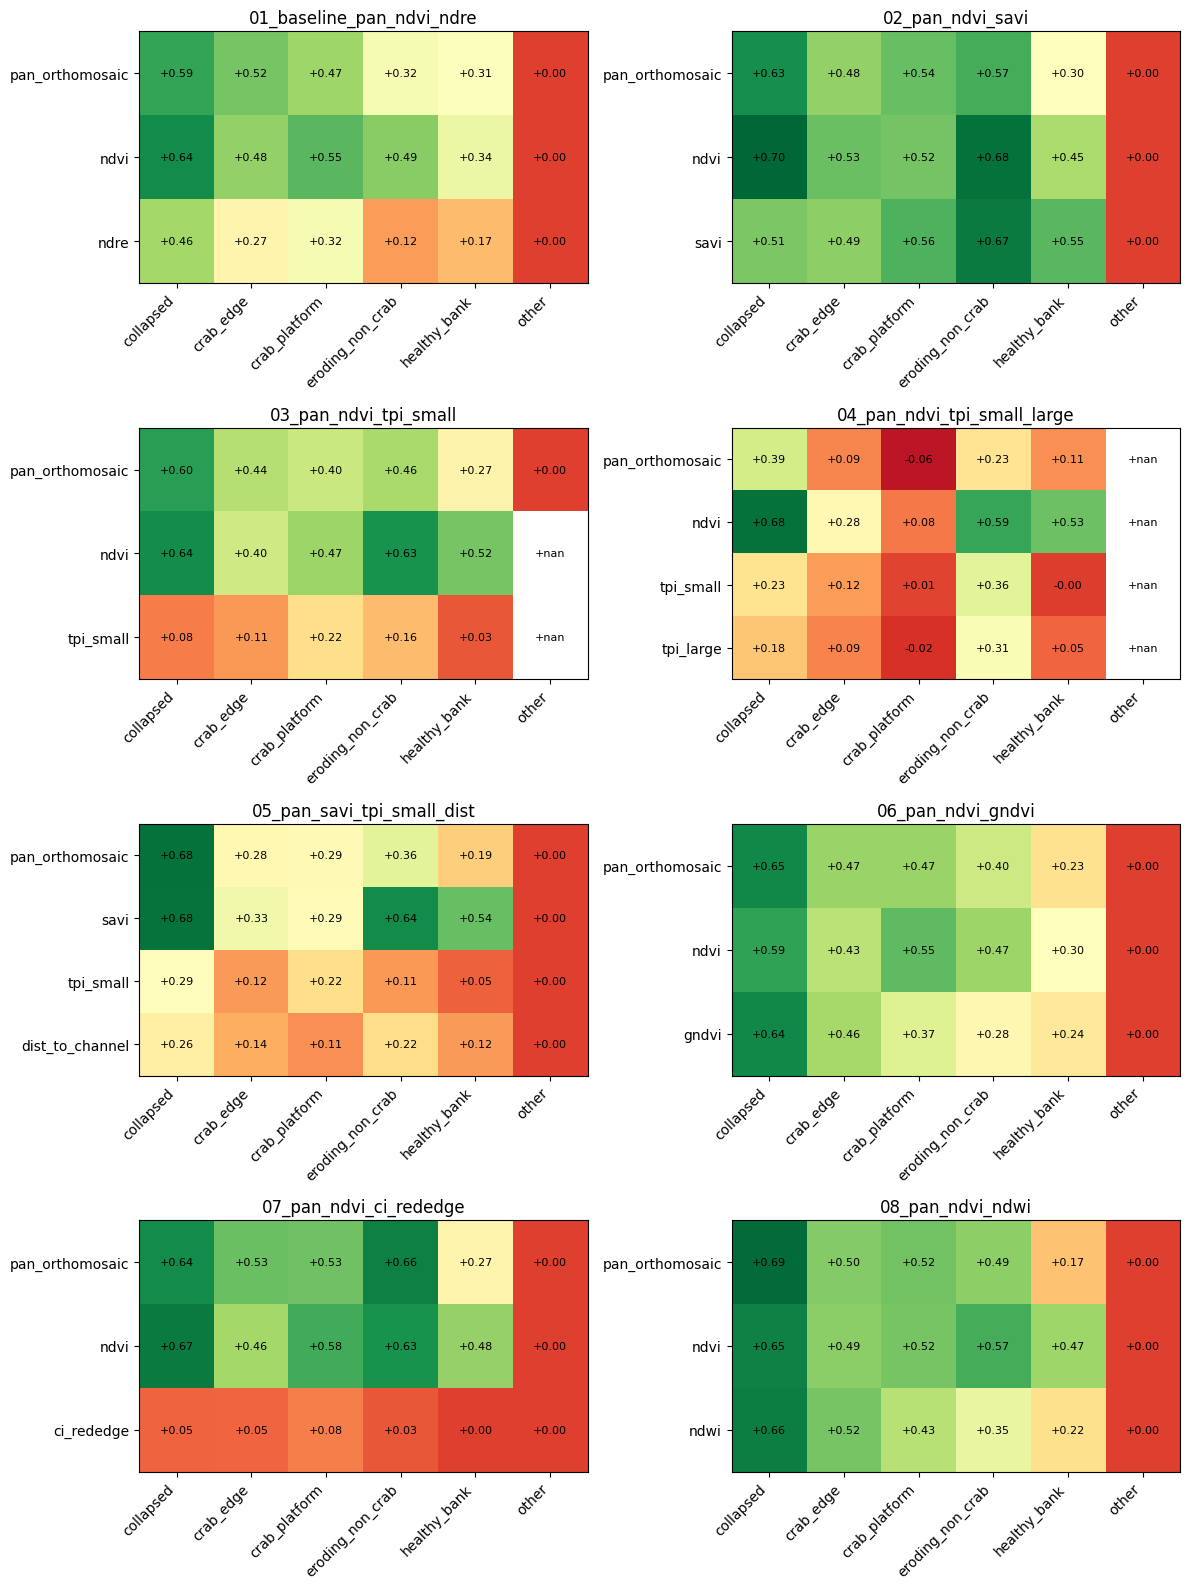

In [33]:
be.show_perm_grid(results);